# Example 1: IMQ-RBF Reconstruction for the Wave Equation

This notebook implements the divided-difference + IMQ-RBF approach discussed in the chat.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

In [2]:
a,b=-1.0,1.0
h=0.01
tau=0.01
T=1.0
s=0.8
K=8

x=np.arange(a,b+h,h)

def exact_solution(x,t):
    return np.sin(np.pi*x)*np.cos(np.pi*t)

u0=np.sin(np.pi*x)

In [3]:
def imq(r,s):
    return s**2/(s**2+r**2)**1.5

center_idx=np.arange(1,len(x)-1,K)
xc=x[center_idx]

def second_difference(u,centers,h):
    d2=np.zeros(len(centers))
    for j,k in enumerate(centers):
        d2[j]=(u[k+1]-2*u[k]+u[k-1])/h**2
    return d2

def build_matrix(xc,s):
    R=np.abs(xc[:,None]-xc[None,:])
    return imq(R,s)

A=build_matrix(xc,s)

def reconstruct_uxx(x,xc,alpha,s):
    R=np.abs(x[:,None]-xc[None,:])
    return imq(R,s)@alpha

In [4]:
d2=second_difference(u0,center_idx,h)
alpha=solve(A,d2)
uxx0=reconstruct_uxx(x,xc,alpha,s)

u_prev=u0.copy()
u_curr=u0+0.5*tau**2*uxx0
u_curr[0]=0
u_curr[-1]=0

nt=int(T/tau)

for _ in range(1,nt):
    d2=second_difference(u_curr,center_idx,h)
    alpha=solve(A,d2)
    uxx=reconstruct_uxx(x,xc,alpha,s)

    u_next=2*u_curr-u_prev+tau**2*uxx
    u_next[0]=0
    u_next[-1]=0

    u_prev=u_curr
    u_curr=u_next

L_inf = 0.921743268683103
RMS = 0.23521471941690747


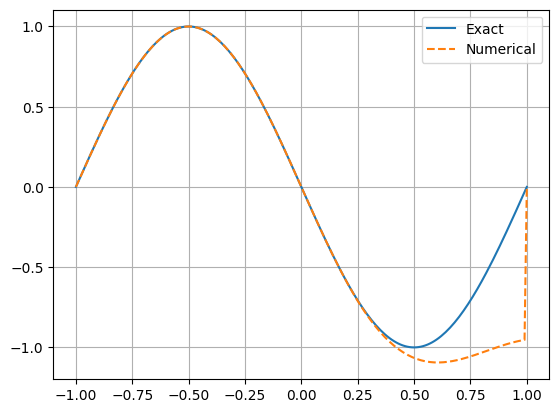

In [5]:
u_exact=exact_solution(x,T)

linf=np.max(np.abs(u_curr-u_exact))
rms=np.sqrt(np.mean((u_curr-u_exact)**2))

print("L_inf =",linf)
print("RMS =",rms)

plt.plot(x,u_exact,label="Exact")
plt.plot(x,u_curr,'--',label="Numerical")
plt.legend()
plt.grid()
plt.show()